### This notebook is for calculating depth-integrated diatom biomass (0-100 m) each year for comparison with "cold" vs. "warm" NPGO years. 

#### Calculations for mean diatom biomass over the May-July, the critical period for juvenile salmon in the Sea Sea are at the end of the notebook.

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
from salishsea_tools import viz_tools, places, visualisations
from matplotlib import pyplot as plt, dates
from datetime import datetime, timedelta
from calendar import month_name
from scipy.io import loadmat
from tqdm.notebook import tqdm
from salishsea_tools import nc_tools
from dask.diagnostics import ProgressBar
import cmocean
from pathlib import Path
import arrow

%matplotlib inline

In [2]:
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 'medium'})

### Load files from monthly averages

In [3]:
# Load monthly averages
mask = xr.open_dataset('/ocean/ksuchy/MOAD/NEMO-forcing/grid/mesh_mask202108.nc')
slc = {'y': slice(450,500), 'x': slice(250,300)} #coordinates for 201905 are y and x
e3t, tmask = [mask[var].isel(z=slice(None, 27),**slc).values for var in ('e3t_0', 'tmask')]
years, variables = range(2007, 2026), ['diatoms']


# Temporary list dict
data = {}


# Permanent aggregate dict
aggregates = {var: {} for var in variables}



slc = {'gridY': slice(450,500), 'gridX': slice(250,300)} #redefine with gridY and gridX for biol dataset because there are new coordinate names for 202111 model run

# Loop through years
for year in years:
    jan = arrow.get(f"{year}-01-01")
    dec = arrow.get(f"{year}-12-01")
    
    for var in variables: 
        data[var] = []
    # Load monthly averages 
    months = arrow.Arrow.range("month", jan, dec)
    for month in months:
        yyyymmdd_first = month.format("YYYYMMDD")
        yyyymmdd_last = month.shift(months=+1).shift(days=-1).format("YYYYMMDD")
        ds_file = f"/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_biol_T_{yyyymmdd_first}_{yyyymmdd_last}.nc"
   
        
        # Load grazing variables
        with xr.open_dataset(ds_file) as ds:
            for var in ['diatoms']:
                data[var].append(np.ma.masked_where(tmask == 0, ds[var].isel(depth=slice(None, 27), **slc).values * e3t).sum(axis=1).data)
    
    # Concatenate months
    for var in variables: aggregates[var][year] = np.concatenate(data[var]).mean(axis=0)
        
        
# Calculate climatological mean and anomalies
for var in variables:
    aggregates[var]['mean'] = np.concatenate([aggregates[var][year][None, ...] for year in years]).mean(axis=0)
    for year in years: aggregates[var][year] = aggregates[var][year] - aggregates[var]['mean']

In [4]:
print(np.shape(aggregates['diatoms'][2015][:]))

(50, 50)


In [5]:
# Reset variables for plotting
tmask = tmask[0, 0, ...]
variables = ['diatoms']

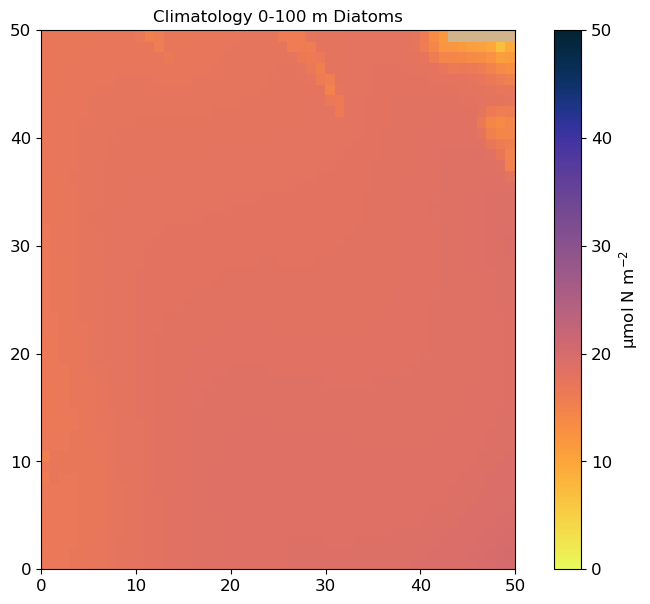

In [6]:
##### with pcolormesh: no smoothing
cmap0=cmocean.cm.balance
cmap0.set_bad('tan')
vmin=0
vmax=50
cmap1=cmocean.cm.thermal_r
cmap1.set_bad('tan')
il=0

fig,ax=plt.subplots(1,1,figsize=(10,7))
#fig.suptitle('Annual Anomalies Mesozoop Feeding on Diatoms', fontsize=16)
m0=ax.pcolormesh(np.ma.masked_where(tmask==0,((aggregates['diatoms']['mean']))),cmap=cmap1,vmin=vmin,vmax=vmax)
viz_tools.set_aspect(ax,coords='grid')
ax.set_title('Climatology 0-100 m Diatoms')
fig.colorbar(m0,ax=ax,label='\u03bcmol N m$^{-2}$')




In [7]:

#years, months, data
monthly_array_diatoms_depthint_slice = np.zeros([19,12,50,50])
# Load monthly averages
mask = xr.open_dataset('/ocean/ksuchy/MOAD/NEMO-forcing/grid/mesh_mask202108.nc')
slc = {'y': slice(450,500), 'x': slice(250,300)}
e3t, tmask = [mask[var].isel(z=slice(None, 27),**slc).values for var in ('e3t_0', 'tmask')]
years, variables = range(2007, 2026), ['diatoms']

# Temporary list dict
data = {}
# Permanent aggregate dict
aggregates = {var: {} for var in variables}
monthlydat = {var: {} for var in variables}
slc = {'gridY': slice(450,500), 'gridX': slice(250,300)} #redefine with gridY and gridX for biol dataset because there are new coordinate names for 202111 model run



# Loop through years
for year in years:
    jan = arrow.get(f"{year}-01-01")
    dec = arrow.get(f"{year}-12-01")
    
    for var in variables: 
        data[var] = []
    # Load monthly averages 
    months = arrow.Arrow.range("month", jan, dec)
    for month in months:
        yyyymmdd_first = month.format("YYYYMMDD")
        yyyymmdd_last = month.shift(months=+1).shift(days=-1).format("YYYYMMDD")
        ds_file = f"/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_biol_T_{yyyymmdd_first}_{yyyymmdd_last}.nc"
   
        
        
        # Load grazing variables
        with xr.open_dataset(ds_file) as ds:
            q = np.ma.masked_where(tmask == 0, ds[var].isel(depth=slice(None, 27), **slc).values * e3t).sum(axis=1).data
            q2 = q[0,:,:]
            monthly_array_diatoms_depthint_slice[year-2007,month.month-1,:,:] = q2 #month.month changes arrow object to integers
            for var in ['diatoms']:
                data[var].append(np.ma.masked_where(tmask == 0, ds[var].isel(depth=slice(None, 27), **slc).values * e3t).sum(axis=1).data)
    
    # Concatenate months
    for var in variables: aggregates[var][year] = np.concatenate(data[var]).mean(axis=0) #[year] might have to be changed with arrow "year.year"?



In [8]:
monthly_array_diatoms_depthint_slice[monthly_array_diatoms_depthint_slice == 0 ] = np.nan
monthly_array_diatoms_depthint_slicemean = \
np.nanmean(np.nanmean(monthly_array_diatoms_depthint_slice, axis = 2),axis = 2)
print(np.shape(monthly_array_diatoms_depthint_slicemean))



(19, 12)


### Select 4 warmest and 4 coldest years; leave NPGO "neutral" years out (based on Suchy et al. 2025 NPGO paper)

In [11]:
#2008, 2010, 2011, 2012
NPGO_C=np.array([[monthly_array_diatoms_depthint_slicemean[1,:]],[monthly_array_diatoms_depthint_slicemean[3,:]],\
        [monthly_array_diatoms_depthint_slicemean[4,:]],[monthly_array_diatoms_depthint_slicemean[5,:]]])

In [12]:
NPGO_C_mean=NPGO_C.mean(axis=0).flatten()

In [13]:
NPGO_C_std=NPGO_C.std(axis=0).flatten()

In [14]:
NPGO_C_mean

array([15.37722214, 20.22918986, 31.60906652, 47.87667656, 33.93694623,
       17.68525767,  7.84887737,  5.99102617, 10.67917692, 10.86792045,
       11.14652574, 13.491041  ])

In [15]:
NPGO_C_std

array([0.71457311, 1.33995749, 5.11319712, 4.08483265, 4.74114137,
       2.28554621, 1.27385583, 1.17153742, 2.69578959, 0.49674668,
       0.53390314, 0.73850377])

In [16]:
#2015, 2018, 2019, 2020
NPGO_W=np.array([[monthly_array_diatoms_depthint_slicemean[8,:]],[monthly_array_diatoms_depthint_slicemean[11,:]],\
        [monthly_array_diatoms_depthint_slicemean[12,:]],[monthly_array_diatoms_depthint_slicemean[13,:]]])


In [17]:
NPGO_W_mean=NPGO_W.mean(axis=0).flatten()

In [18]:
NPGO_W_std=NPGO_W.std(axis=0).flatten()

In [19]:
NPGO_W_mean

array([15.2439818 , 20.79141181, 42.28765336, 39.30864106, 29.92417963,
       10.96824675,  5.48241495,  5.02358361,  8.70333237, 10.69049248,
       10.80976497, 12.52015169])

In [20]:
NPGO_W_std

array([1.23901329, 1.32574397, 5.80127735, 2.27218796, 2.21714141,
       0.87728765, 0.5963925 , 0.84614823, 1.30593674, 0.74031533,
       0.54556503, 0.45934391])

### Plot used in the SOPO presentations:

Text(0, 0.5, 'mmol N m$^{-2}$')

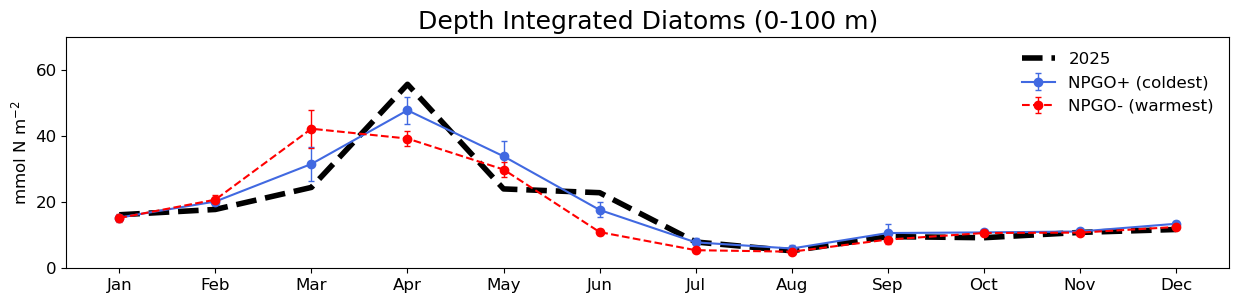

In [23]:
fig, ax = plt.subplots(figsize=(15, 3))
bbox = {'boxstyle': 'round', 'facecolor': 'w', 'alpha': 0.9}
cmap = plt.get_cmap('tab10')
palette = [cmap(0), cmap(0.2), 'k', cmap(0.1), cmap(0.3)]
xticks=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov',"Dec"]

#ax.plot(np.arange(1,13), NPGO_C_mean,label='NPGO+ coldest')
ax.errorbar(xticks,NPGO_C_mean,yerr=NPGO_C_std,fmt='o',linestyle='-',color='royalblue',ecolor = 'royalblue', elinewidth = 1, capsize = 2,label='NPGO+ (coldest)')
#ax.plot(np.arange(1,13), NPGO_W_mean,linestyle='--',label='NPGO- warmest',color='r')
ax.errorbar(xticks,NPGO_W_mean,yerr=NPGO_W_std,fmt='o',linestyle='--',color='r',ecolor = 'r', elinewidth = 1, capsize = 2,label='NPGO- (warmest)')
ax.plot(xticks, monthly_array_diatoms_depthint_slicemean[18,:],color='k',linestyle='--',label='2025',linewidth=4)
ax.set_title('Depth Integrated Diatoms (0-100 m)',fontsize=18)
ax.legend(frameon=False)
ax.set_ylim(0,70)
ax.set_ylabel('mmol N m$^{-2}$',fontsize=12)

In [33]:
## Calculate the climatology over May, June, and July
mjj_climatology=(monthly_array_diatoms_depthint_slicemean[0,(4,5,6)]+\
            monthly_array_diatoms_depthint_slicemean[1,(4,5,6)]+\
            monthly_array_diatoms_depthint_slicemean[2,(4,5,6)]+monthly_array_diatoms_depthint_slicemean[3,(4,5,6)]+\
            monthly_array_diatoms_depthint_slicemean[4,(4,5,6)]+monthly_array_diatoms_depthint_slicemean[5,(4,5,6)]+\
            monthly_array_diatoms_depthint_slicemean[6,(4,5,6)]+monthly_array_diatoms_depthint_slicemean[7,(4,5,6)]+\
            monthly_array_diatoms_depthint_slicemean[8,(4,5,6)]+monthly_array_diatoms_depthint_slicemean[9,(4,5,6)]+\
            monthly_array_diatoms_depthint_slicemean[10,(4,5,6)]+monthly_array_diatoms_depthint_slicemean[11,(4,5,6)]+\
            monthly_array_diatoms_depthint_slicemean[12,(4,5,6)]+monthly_array_diatoms_depthint_slicemean[13,(4,5,6)]+\
                monthly_array_diatoms_depthint_slicemean[14,(4,5,6)]+monthly_array_diatoms_depthint_slicemean[15,(4,5,6)]+\
                monthly_array_diatoms_depthint_slicemean[16,(4,5,6)]+monthly_array_diatoms_depthint_slicemean[17,(4,5,6)]+\
                          +monthly_array_diatoms_depthint_slicemean[18,(4,5,6)])/19

In [34]:
np.shape(mjj_climatology)

(3,)

In [35]:
## This is the critical period for juvenile salmon feeding in the Salish Sea
criticalperiod=np.mean(mjj_climatology[0:3],axis=0)

In [36]:
np.shape(monthly_array_diatoms_depthint_slicemean)

(19, 12)

In [37]:
criticalperiod

17.340435535290492

In [38]:
np.mean(np.mean(monthly_array_diatoms_depthint_slicemean[4:7],axis=1))

18.26106504430547

In [39]:
monthly_array_diatoms_depthint_slicemean[0,4:7].mean()

18.29914204998696

In [40]:
### Print the annual values for plotting in SOPO2025_NPGOvsDiatomAnomalies.ipynb


print(
(monthly_array_diatoms_depthint_slicemean[0,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[1,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[2,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[3,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[4,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[5,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[6,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[7,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[8,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[9,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[10,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[11,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[12,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[13,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[14,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[15,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[16,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[17,4:7].mean())-criticalperiod,
(monthly_array_diatoms_depthint_slicemean[18,4:7].mean())-criticalperiod)


0.9587065146964662 3.785497592122365 0.8896491349344053 3.4246816726590907 0.03985877809441973 2.6829948384908633 1.9587023692838912 -2.231737575765452 -2.0549345185938357 0.2508894109322881 -1.9942306040694913 -2.29230019142663 -0.6503592176858035 -2.5310264467240593 -1.7844261839645608 -1.2502707398637156 -0.7150275183785162 0.5480416700217923 0.9652910152364171
